--- ข้อมูลเบื้องต้นของ Dataset ---
      Name Weapon Type  Price  Fire Rate Wall Penetration  Magazine Capacity  \
0  Classic     Sidearm      0       6.75              Low                 12   
1   Shorty     Sidearm    200       3.30              Low                  2   
2   Frenzy     Sidearm    400      10.00              Low                 13   
3    Ghost     Sidearm    500       6.75           Medium                 15   
4  Sheriff     Sidearm    800       4.00             High                  6   

   HDMG_0  BDMG_0  LDMG_0  HDMG_1  BDMG_1  LDMG_1  HDMG_2  BDMG_2  LDMG_2  
0      78      26      22      78      26      22      66      22      18  
1      36      12      10      24       8       6       9       3       2  
2      78      26      22      63      21      17      63      21      17  
3     105      33      26      88      25      21      88      25      21  
4     160      55      47     160      55      47     145      50      43  

=== [PART 1] Simple Linear 

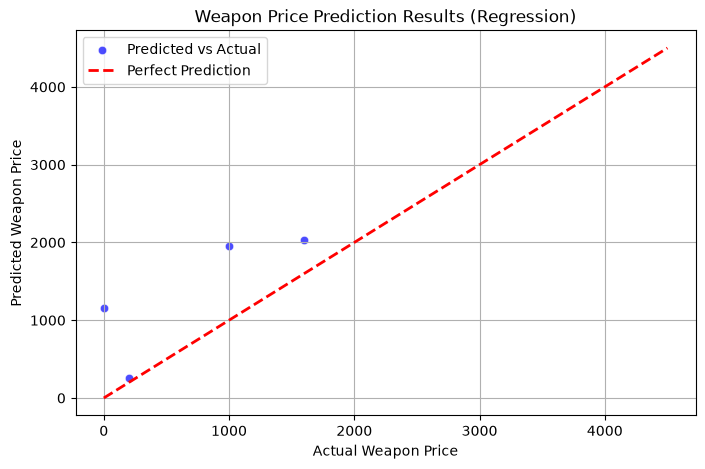

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Load Dataset
df = pd.read_csv(r"E:\valorant-stats.csv")
print("--- ข้อมูลเบื้องต้นของ Dataset ---")
print(df.head())

# =========================================================================
# PART 1: Simple Linear Regression
# สมมติฐาน: อัตราการยิง (Fire Rate) มีความสัมพันธ์กับราคา (Price)
# =========================================================================
print("\n=== [PART 1] Simple Linear Regression ===")

X_simple = df[['Fire Rate']]
y = df['Price']

# Split Data
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y, test_size=0.2, random_state=42)

# Train Model
simple_model = LinearRegression()
simple_model.fit(X_train_s, y_train_s)

# Predict & Evaluate
y_pred_s = simple_model.predict(X_test_s)
print(f"Simple Reg - R² Score: {r2_score(y_test_s, y_pred_s):.4f}")
print(f"Simple Reg - MSE: {mean_squared_error(y_test_s, y_pred_s):.4f}")


# =========================================================================
# PART 2: Multiple Linear Regression & PCA (ตามวัตถุประสงค์ของแล็บ)
# ใช้ฟีเจอร์ด้านปืนและดาเมจในการทำนายราคา
# =========================================================================
print("\n=== [PART 2] Multiple Linear Regression with PCA ===")

# เลือกคุณลักษณะที่เป็นตัวเลข (Features)
features = ['Fire Rate', 'Magazine Capacity', 'HDMG_0', 'BDMG_0', 'LDMG_0', 'HDMG_1', 'BDMG_1', 'LDMG_1']
X_multi = df[features]

# ขั้นตอนการเตรียมข้อมูล: Standardize Features ก่อนทำ PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_multi)

# ประยุกต์ใช้ PCA เพื่อลดมิติข้อมูล (เหลือ 2 Components หลัก)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"สัดส่วนความอธิบายความแปรปรวนของ PCA (Variance Ratio): {pca.explained_variance_ratio_}")

# Split Data (ข้อมูลที่ผ่าน PCA แล้ว)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Train Multiple Linear Regression
multi_model = LinearRegression()
multi_model.fit(X_train_m, y_train_m)


# =========================================================================
# PART 3: Weapon Price Prediction & Evaluation (หัวข้อที่ปรับปรุงใหม่)
# =========================================================================
print("\n=== [PART 3] Weapon Price Prediction & Evaluation ===")

# Predict
y_pred_m = multi_model.predict(X_test_m)

# Evaluation Metrics สำหรับ Regression (ตามแนวทางตัวชี้วัดที่เหมาะสม)
mae = mean_absolute_error(y_test_m, y_pred_m)
mse = mean_squared_error(y_test_m, y_pred_m)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_m, y_pred_m)

print(f"ตัวชี้วัดการประเมินผลโมเดล (Multiple Regression + PCA):")
print(f"- Mean Absolute Error (MAE): {mae:.2f}")
print(f"- Mean Squared Error (MSE): {mse:.2f}")
print(f"- Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"- R-squared (R² Score): {r2:.4f}")

# เปรียบเทียบผลลัพธ์จริง กับ ผลทำนาย
comparison_df = pd.DataFrame({'Actual Price': y_test_m, 'Predicted Price': y_pred_m.round(2)})
print("\nตัวอย่างผลการทำนายราคา:")
print(comparison_df.head())

# Visualizing the Results (สร้างกราฟเปรียบเทียบ)
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test_m, y=y_pred_m, color='blue', alpha=0.7, label='Predicted vs Actual')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Weapon Price')
plt.ylabel('Predicted Weapon Price')
plt.title('Weapon Price Prediction Results (Regression)')
plt.legend()
plt.grid(True)
plt.show()


=== 1. Preparing Data ===
จำนวนข้อมูลตามคลาส (0: Non-High, 1: High Wall Penetration):
Target
0    13
1     4
Name: count, dtype: int64
--------------------------------------------------
=== 2. Logistic Regression Results ===
Accuracy: 0.8235

Classification Report:
              precision    recall  f1-score   support

  Low/Medium       0.81      1.00      0.90        13
        High       1.00      0.25      0.40         4

    accuracy                           0.82        17
   macro avg       0.91      0.62      0.65        17
weighted avg       0.86      0.82      0.78        17

--------------------------------------------------


c:\Users\USER01\Desktop\heart\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


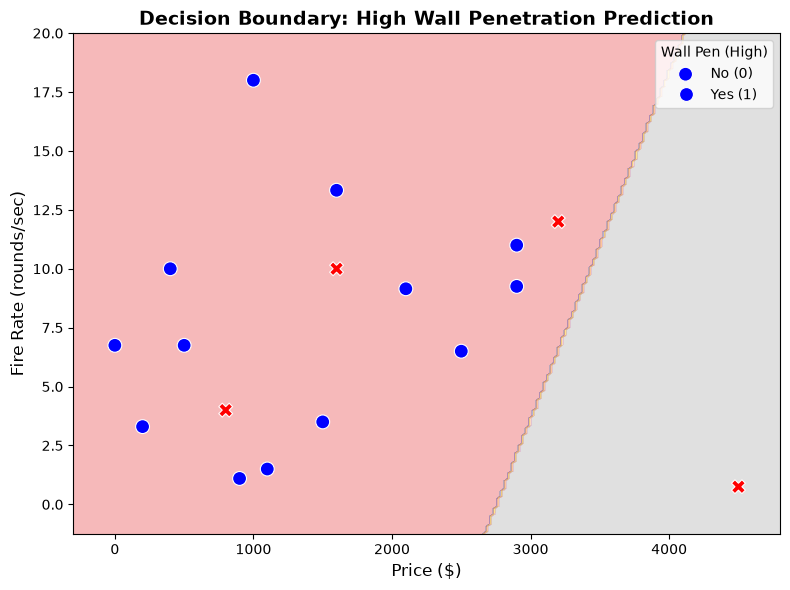

<Figure size 600x500 with 0 Axes>

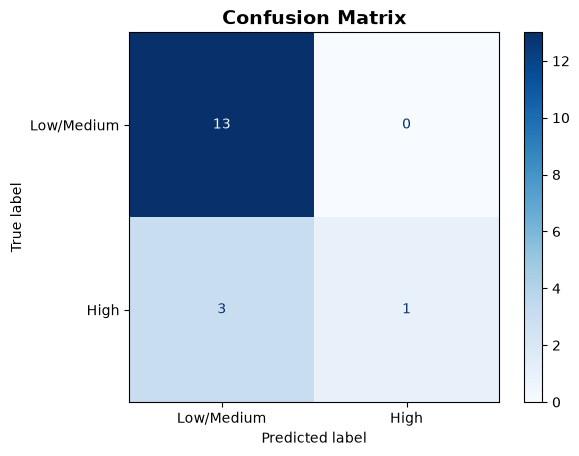

In [ ]:
#LAB 2: Classification 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 1. โหลดข้อมูล
file_path = r"E:\valorant-stats.csv"  # เปลี่ยน Path ตามตำแหน่งไฟล์ของคุณ
df = pd.read_csv(file_path)

# ==========================================
# 1. Preparing Classification Data
# (สร้าง Target: จำแนกปืนเจาะทะลุกำแพงสูง High Wall Penetration = 1, อื่นๆ = 0)
# ==========================================
df['Target'] = (df['Wall Penetration'] == 'High').astype(int)

# เลือก 2 Features เพื่อให้สร้าง Decision Boundary ได้ง่าย (Price และ Fire Rate)
X = df[['Price', 'Fire Rate']]
y = df['Target']

print("=== 1. Preparing Data ===")
print("จำนวนข้อมูลตามคลาส (0: Non-High, 1: High Wall Penetration):")
print(y.value_counts())
print("-" * 50)

# ==========================================
# 2. Logistic Regression
# ==========================================
model = LogisticRegression()
model.fit(X, y)
y_pred = model.predict(X)

print("=== 2. Logistic Regression Results ===")
print(f"Accuracy: {model.score(X, y):.4f}")
print("\nClassification Report:")
print(classification_report(y, y_pred, target_names=['Low/Medium', 'High']))
print("-" * 50)

# ==========================================
# 3. Decision Boundary Visualization
# ==========================================
plt.figure(figsize=(8, 6))

# สร้าง Grid สำหรับวาดเส้นแบ่งเขต (Decision Boundary)
x_min, x_max = X['Price'].min() - 300, X['Price'].max() + 300
y_min, y_max = X['Fire Rate'].min() - 2, X['Fire Rate'].max() + 2
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# ทำนายค่าบน Grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# วาด Decision Boundary
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Set1')

# พล็อตจุดข้อมูล
sns.scatterplot(
    data=df, 
    x='Price', 
    y='Fire Rate', 
    hue='Target', 
    style='Target',
    palette={0: 'blue', 1: 'red'},
    s=100
)

plt.title("Decision Boundary: High Wall Penetration Prediction", fontsize=14, fontweight='bold')
plt.xlabel("Price ($)", fontsize=12)
plt.ylabel("Fire Rate (rounds/sec)", fontsize=12)
plt.legend(title="Wall Pen (High)", labels=['No (0)', 'Yes (1)'])
plt.tight_layout()
plt.show()

# ==========================================
# 4. Confusion Matrix
# ==========================================
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low/Medium', 'High'])
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix", fontsize=14, fontweight='bold')
plt.show()

 📊 LAB 3: MODEL PERFORMANCE METRICS COMPARISON

--- [1] REGRESSION METRICS (Train vs Test) ---
   Metric  Simple Linear Reg  Multiple Linear Reg
 Train R²       7.713146e-03             0.540013
  Test R²      -3.810817e+00             0.262334
Train MSE       1.385914e+06        642457.134072
 Test MSE       1.972435e+06        302442.950261

--------------------------------------------------

--- [2] CLASSIFICATION METRICS (Logistic Regression) ---
   Metric  Train Performance  Test Performance
 Accuracy           0.846154              0.75
Precision           0.666667              0.00
   Recall           0.666667              0.00
 F1-Score           0.666667              0.00


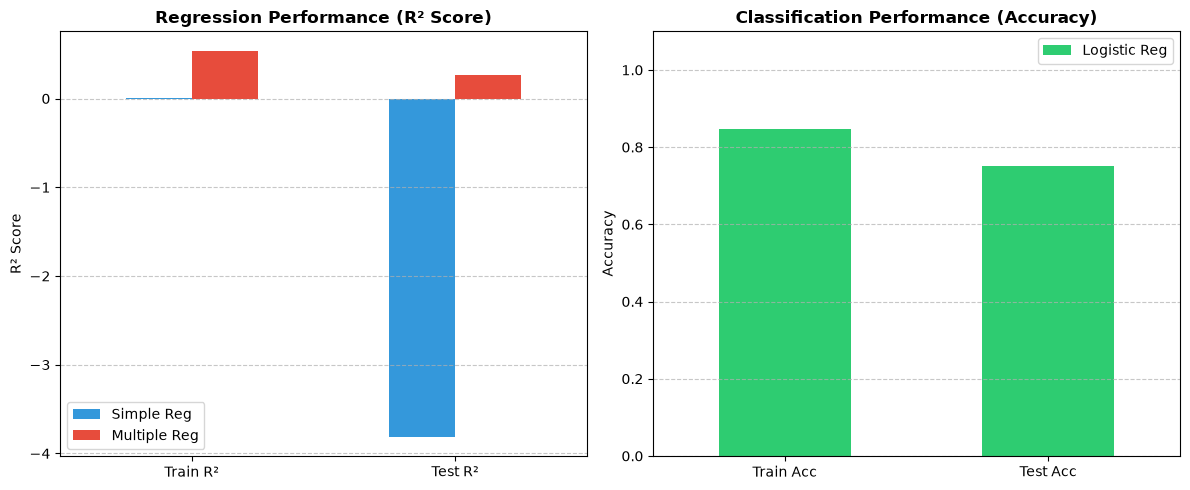

In [7]:
#LAB 3: Model Comparison

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score

# 1. โหลดข้อมูล
file_path = r"E:\valorant-stats.csv"  # เปลี่ยน Path ตามตำแหน่งไฟล์ของคุณ
df = pd.read_csv(file_path)

# ==========================================
# 📌 1. Preparing Data & Train/Test Split
# ==========================================
# Regression Target: ราคาปืน (Price)
y_reg = df['Price']
X_simple = df[['Fire Rate']]
X_multi = df[['Fire Rate', 'Magazine Capacity', 'HDMG_0']]

# Classification Target: เจาะทะลุกำแพงสูง (High Wall Penetration = 1, อื่นๆ = 0)
y_cls = (df['Wall Penetration'] == 'High').astype(int)

# แบ่งข้อมูล Training Set (80%) และ Testing Set (20%)
X_tr_s, X_te_s, y_tr_reg, y_te_reg = train_test_split(X_simple, y_reg, test_size=0.2, random_state=42)
X_tr_m, X_te_m, _, _ = train_test_split(X_multi, y_reg, test_size=0.2, random_state=42)
X_tr_c, X_te_c, y_tr_cls, y_te_cls = train_test_split(X_multi, y_cls, test_size=0.2, random_state=42)

# ==========================================
# 📌 2. Training Models
# ==========================================
# Model 1: Simple Linear Regression
reg_simple = LinearRegression().fit(X_tr_s, y_tr_reg)

# Model 2: Multiple Linear Regression
reg_multi = LinearRegression().fit(X_tr_m, y_tr_reg)

# Model 3: Logistic Regression (Classification)
clf = LogisticRegression().fit(X_tr_c, y_tr_cls)

# ==========================================
# 📌 3. Evaluating & Metrics Comparison
# ==========================================
print("==================================================")
print(" 📊 LAB 3: MODEL PERFORMANCE METRICS COMPARISON")
print("==================================================\n")

# --- 3.1 Simple vs Multiple Linear Regression ---
print("--- [1] REGRESSION METRICS (Train vs Test) ---")
reg_metrics = pd.DataFrame({
    'Metric': ['Train R²', 'Test R²', 'Train MSE', 'Test MSE'],
    'Simple Linear Reg': [
        r2_score(y_tr_reg, reg_simple.predict(X_tr_s)),
        r2_score(y_te_reg, reg_simple.predict(X_te_s)),
        mean_squared_error(y_tr_reg, reg_simple.predict(X_tr_s)),
        mean_squared_error(y_te_reg, reg_simple.predict(X_te_s))
    ],
    'Multiple Linear Reg': [
        r2_score(y_tr_reg, reg_multi.predict(X_tr_m)),
        r2_score(y_te_reg, reg_multi.predict(X_te_m)),
        mean_squared_error(y_tr_reg, reg_multi.predict(X_tr_m)),
        mean_squared_error(y_te_reg, reg_multi.predict(X_te_m))
    ]
})
print(reg_metrics.to_string(index=False))

print("\n" + "-" * 50 + "\n")

# --- 3.2 Classification Performance Metrics ---
print("--- [2] CLASSIFICATION METRICS (Logistic Regression) ---")
y_pred_tr_c = clf.predict(X_tr_c)
y_pred_te_c = clf.predict(X_te_c)

cls_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Train Performance': [
        accuracy_score(y_tr_cls, y_pred_tr_c),
        precision_score(y_tr_cls, y_pred_tr_c, zero_division=0),
        recall_score(y_tr_cls, y_pred_tr_c, zero_division=0),
        f1_score(y_tr_cls, y_pred_tr_c, zero_division=0)
    ],
    'Test Performance': [
        accuracy_score(y_te_cls, y_pred_te_c),
        precision_score(y_te_cls, y_pred_te_c, zero_division=0),
        recall_score(y_te_cls, y_pred_te_c, zero_division=0),
        f1_score(y_te_cls, y_pred_te_c, zero_division=0)
    ]
})
print(cls_metrics.to_string(index=False))

# ==========================================
# 📌 4. Visualizing Train vs Test Comparison
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Regression (R² Score)
r2_data = {
    'Simple Reg': [r2_score(y_tr_reg, reg_simple.predict(X_tr_s)), r2_score(y_te_reg, reg_simple.predict(X_te_s))],
    'Multiple Reg': [r2_score(y_tr_reg, reg_multi.predict(X_tr_m)), r2_score(y_te_reg, reg_multi.predict(X_te_m))]
}
df_r2 = pd.DataFrame(r2_data, index=['Train R²', 'Test R²'])
df_r2.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'], rot=0)
axes[0].set_title('Regression Performance (R² Score)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: Classification (Accuracy)
acc_data = {
    'Logistic Reg': [accuracy_score(y_tr_cls, y_pred_tr_c), accuracy_score(y_te_cls, y_pred_te_c)]
}
df_acc = pd.DataFrame(acc_data, index=['Train Acc', 'Test Acc'])
df_acc.plot(kind='bar', ax=axes[1], color=['#2ecc71'], rot=0)
axes[1].set_title('Classification Performance (Accuracy)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()